In [75]:
import sys
import json
import yaml
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Add project root to path
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root / "src"))

from bonn_thesis.config import OCCUPATION_DATA_BLD, SRC

# Sklearn for metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Fine-Tuned ISCO Classifier Evaluation

Evaluation of the fine-tuned model on manually coded test data.

## 1. Load Data

In [76]:
# Define file paths
input_dir = OCCUPATION_DATA_BLD / "openai_inputs"
response_dir = OCCUPATION_DATA_BLD / "openai_responses"

manual_classification_file = input_dir / "isco_classification_test_data.csv"
model_results_file = response_dir / "isco_classification_test_data_results.jsonl"

print(f"Manual classifications: {manual_classification_file}")
print(f"Model results: {model_results_file}")
print(f"\nFiles exist:")
print(f"  Manual: {manual_classification_file.exists()}")
print(f"  Model: {model_results_file.exists()}")

Manual classifications: /Users/willbackes/Documents/code/bonn_thesis/bld/data/occupation_data/openai_inputs/isco_classification_test_data.csv
Model results: /Users/willbackes/Documents/code/bonn_thesis/bld/data/occupation_data/openai_responses/isco_classification_test_data_results.jsonl

Files exist:
  Manual: True
  Model: True


In [77]:
# Load manual classifications
manual_data = pd.read_csv(manual_classification_file)

print(f"Manual classifications loaded: {len(manual_data)} examples")
print(f"\nColumns: {manual_data.columns.tolist()}")
print(f"\nFirst few rows:")
manual_data.head()

Manual classifications loaded: 300 examples

Columns: ['custom_id', 'content', 'isco_code', 'confidence_score']

First few rows:


,custom_id,content,isco_code,confidence_score
0,isco_classification_427_15849874,Digital Marketing Manager. Industry: Marketing...,243.0,5.0
1,isco_classification_056_2099193,Key Account Manager. Industry: Staffing & Recr...,332.0,2.0
2,isco_classification_013_463081,Project Manager. Industry: Machinery,242.0,1.0
3,isco_classification_481_17828562,Senior Solution Architect. Industry: Computer ...,251.0,3.0
4,isco_classification_162_5799554,Rechtsreferendarin. Industry: Law Practice,261.0,5.0


In [78]:
# Load model predictions from JSONL
def load_predictions_from_jsonl(file_path):
    """Extract predictions from OpenAI batch API results."""
    predictions = []
    
    with open(file_path) as f:
        for line in f:
            result = json.loads(line)
            custom_id = result["custom_id"]
            
            # Extract predicted ISCO code from response
            if result["error"] is None:
                predicted_code = result["response"]["body"]["choices"][0]["message"]["content"]
                predictions.append({
                    "custom_id": custom_id,
                    "predicted_isco": predicted_code
                })
            else:
                # Handle errors
                predictions.append({
                    "custom_id": custom_id,
                    "predicted_isco": None,
                    "error": result["error"]
                })
    
    return pd.DataFrame(predictions)

model_predictions = load_predictions_from_jsonl(model_results_file)

print(f"Model predictions loaded: {len(model_predictions)} examples")
print(f"\nFirst few predictions:")
model_predictions.head()

Model predictions loaded: 300 examples

First few predictions:


,custom_id,predicted_isco
0,isco_classification_427_15849874,243
1,isco_classification_056_2099193,333
2,isco_classification_013_463081,311
3,isco_classification_481_17828562,251
4,isco_classification_162_5799554,261


## 2. Merge and Clean Data

## 2a. Load Base Model Results (for Comparison)

Load predictions from the non-fine-tuned base model to compare performance improvements from fine-tuning.

In [79]:
# Load base model predictions
base_model_file = response_dir / "isco_classification_test_data_base_model_results.jsonl"

print(f"Base model results: {base_model_file}")
print(f"File exists: {base_model_file.exists()}")

base_model_predictions = load_predictions_from_jsonl(base_model_file)

print(f"\nBase model predictions loaded: {len(base_model_predictions)} examples")
print(f"First few predictions:")
base_model_predictions.head()

Base model results: /Users/willbackes/Documents/code/bonn_thesis/bld/data/occupation_data/openai_responses/isco_classification_test_data_base_model_results.jsonl
File exists: True

Base model predictions loaded: 300 examples
First few predictions:


,custom_id,predicted_isco
0,isco_classification_427_15849874,243
1,isco_classification_056_2099193,122 Manager of sales and marketing
2,isco_classification_013_463081,122
3,isco_classification_481_17828562,251
4,isco_classification_162_5799554,261


In [80]:
# Merge manual classifications with base model predictions
base_test_data = manual_data.merge(
    base_model_predictions, 
    on="custom_id", 
    how="left", 
    suffixes=('', '_base')
)

# Clean up column names
base_test_data = base_test_data.rename(columns={"isco_code": "true_isco", "predicted_isco": "predicted_isco_base"})

# Convert ISCO codes to strings first for cleaning
base_test_data["true_isco"] = base_test_data["true_isco"].astype(str).str.strip()
base_test_data["predicted_isco_base"] = base_test_data["predicted_isco_base"].astype(str).str.strip().str[:3]

# Create clean dataset (excluding NA)
base_test_data_clean = base_test_data[base_test_data["true_isco"] != "NA"].copy()

# Convert ISCO codes to integers
base_test_data_clean["true_isco"] = pd.to_numeric(base_test_data_clean["true_isco"], errors='coerce')
base_test_data_clean["predicted_isco_base"] = pd.to_numeric(base_test_data_clean["predicted_isco_base"], errors='coerce')

# Drop any rows with NaN values
rows_before = len(base_test_data_clean)
base_test_data_clean = base_test_data_clean.dropna(subset=["true_isco", "predicted_isco_base"])
rows_after = len(base_test_data_clean)
if rows_before != rows_after:
    print(f"Dropped {rows_before - rows_after} rows with invalid ISCO codes")

# Convert to integers
base_test_data_clean["true_isco"] = base_test_data_clean["true_isco"].astype(int)
base_test_data_clean["predicted_isco_base"] = base_test_data_clean["predicted_isco_base"].astype(int)

# Add major groups
base_test_data_clean["true_major_group"] = base_test_data_clean["true_isco"].astype(str).str[0]
base_test_data_clean["predicted_major_group_base"] = base_test_data_clean["predicted_isco_base"].astype(str).str[0]

print(f"Base model - Occupation examples for evaluation: {len(base_test_data_clean)}")
print(f"\nData preview:")
base_test_data_clean[["custom_id", "content", "true_isco", "predicted_isco_base", "confidence_score"]].head(10)

Dropped 15 rows with invalid ISCO codes
Base model - Occupation examples for evaluation: 285

Data preview:


,custom_id,content,true_isco,predicted_isco_base,confidence_score
0,isco_classification_427_15849874,Digital Marketing Manager. Industry: Marketing...,243,243,5.0
1,isco_classification_056_2099193,Key Account Manager. Industry: Staffing & Recr...,332,122,2.0
2,isco_classification_013_463081,Project Manager. Industry: Machinery,242,122,1.0
3,isco_classification_481_17828562,Senior Solution Architect. Industry: Computer ...,251,251,3.0
4,isco_classification_162_5799554,Rechtsreferendarin. Industry: Law Practice,261,261,5.0
5,isco_classification_138_4897170,Development Engineer. Industry: Telecommunicat...,215,214,4.0
6,isco_classification_121_4252820,Software Engineer [Broadcasting Media]. Indust...,251,213,5.0
7,isco_classification_080_2676863,Tax Consultant. Industry: Law Practice,241,241,2.0
8,isco_classification_479_17753215,Senior Engineering Consultant. Industry: Autom...,214,243,2.0
9,isco_classification_052_1955640,Head Of Human Resources Site Freiburg. Industr...,121,121,5.0


In [81]:
# Merge manual classifications with model predictions
test_data = manual_data.merge(model_predictions, on="custom_id", how="left")

# Clean up column names
test_data = test_data.rename(columns={"isco_code": "true_isco"})

# Convert ISCO codes to strings first for cleaning
test_data["true_isco"] = test_data["true_isco"].astype(str).str.strip()
test_data["predicted_isco"] = test_data["predicted_isco"].astype(str).str.strip().str[:3]

# Identify NA values (these are non-occupation entries like leave periods or education)
print(f"Total examples: {len(test_data)}")
print(f"Examples with 'NA' in manual classification: {(test_data['true_isco'] == 'NA').sum()}")
print(f"  Note: NA entries represent non-occupation positions (leave, education, etc.)")

# Create a clean dataset for evaluation (excluding NA)
test_data_clean = test_data[test_data["true_isco"] != "NA"].copy()

# Convert ISCO codes to integers for occupation positions
# Use pd.to_numeric to safely convert, coercing errors to NaN
test_data_clean["true_isco"] = pd.to_numeric(test_data_clean["true_isco"], errors='coerce')
test_data_clean["predicted_isco"] = pd.to_numeric(test_data_clean["predicted_isco"], errors='coerce')

# Drop any rows with NaN values (invalid ISCO codes)
rows_before = len(test_data_clean)
test_data_clean = test_data_clean.dropna(subset=["true_isco", "predicted_isco"])
rows_after = len(test_data_clean)
if rows_before != rows_after:
    print(f"Dropped {rows_before - rows_after} rows with invalid ISCO codes")

# Convert to integers
test_data_clean["true_isco"] = test_data_clean["true_isco"].astype(int)
test_data_clean["predicted_isco"] = test_data_clean["predicted_isco"].astype(int)

print(f"\nOccupation examples for evaluation: {len(test_data_clean)}")
print(f"Non-occupation examples (NA): {(test_data['true_isco'] == 'NA').sum()}")

print(f"\nData preview (occupation positions):")
print(f"Data types: true_isco={test_data_clean['true_isco'].dtype}, predicted_isco={test_data_clean['predicted_isco'].dtype}")
test_data_clean[["custom_id", "content", "true_isco", "predicted_isco", "confidence_score"]].head(10)

Total examples: 300
Examples with 'NA' in manual classification: 0
  Note: NA entries represent non-occupation positions (leave, education, etc.)
Dropped 15 rows with invalid ISCO codes

Occupation examples for evaluation: 285
Non-occupation examples (NA): 0

Data preview (occupation positions):
Data types: true_isco=int64, predicted_isco=int64


,custom_id,content,true_isco,predicted_isco,confidence_score
0,isco_classification_427_15849874,Digital Marketing Manager. Industry: Marketing...,243,243,5.0
1,isco_classification_056_2099193,Key Account Manager. Industry: Staffing & Recr...,332,333,2.0
2,isco_classification_013_463081,Project Manager. Industry: Machinery,242,311,1.0
3,isco_classification_481_17828562,Senior Solution Architect. Industry: Computer ...,251,251,3.0
4,isco_classification_162_5799554,Rechtsreferendarin. Industry: Law Practice,261,261,5.0
5,isco_classification_138_4897170,Development Engineer. Industry: Telecommunicat...,215,215,4.0
6,isco_classification_121_4252820,Software Engineer [Broadcasting Media]. Indust...,251,251,5.0
7,isco_classification_080_2676863,Tax Consultant. Industry: Law Practice,241,241,2.0
8,isco_classification_479_17753215,Senior Engineering Consultant. Industry: Autom...,214,214,2.0
9,isco_classification_052_1955640,Head Of Human Resources Site Freiburg. Industr...,121,121,5.0


In [82]:
# Add major groups (first digit of ISCO code) for occupation positions
test_data_clean["true_major_group"] = test_data_clean["true_isco"].astype(str).str[0]
test_data_clean["predicted_major_group"] = test_data_clean["predicted_isco"].astype(str).str[0]

# ISCO-08 major group names
major_groups = {
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians and Associate Professionals",
    "4": "Clerical Support Workers",
    "5": "Service and Sales Workers",
    "6": "Skilled Agricultural, Forestry and Fishery Workers",
    "7": "Craft and Related Trades Workers",
    "8": "Plant and Machine Operators and Assemblers",
    "9": "Elementary Occupations",
    "0": "Armed Forces Occupations",
}

print("Test Data Summary (Occupation Positions Only):")
print(f"  Total occupation examples: {len(test_data_clean)}")
print(f"  Unique true ISCO codes: {test_data_clean['true_isco'].nunique()}")
print(f"  Unique predicted ISCO codes: {test_data_clean['predicted_isco'].nunique()}")
print(f"  Major groups represented (true): {test_data_clean['true_major_group'].nunique()}")

print("\nMajor group distribution (true labels):")
for group in sorted(test_data_clean["true_major_group"].unique()):
    count = (test_data_clean["true_major_group"] == group).sum()
    name = major_groups.get(group, "Unknown")
    print(f"  {group} - {name}: {count}")
    
# Also analyze NA entries separately
na_data = test_data[test_data["true_isco"] == "NA"]
if len(na_data) > 0:
    print(f"\nNon-Occupation Entries (NA): {len(na_data)}")
    print("Sample NA entries:")
    print(na_data[["custom_id", "content", "confidence_score"]].head())

Test Data Summary (Occupation Positions Only):
  Total occupation examples: 285
  Unique true ISCO codes: 46
  Unique predicted ISCO codes: 54
  Major groups represented (true): 6

Major group distribution (true labels):
  1 - Managers: 51
  2 - Professionals: 177
  3 - Technicians and Associate Professionals: 36
  4 - Clerical Support Workers: 12
  5 - Service and Sales Workers: 8
  9 - Elementary Occupations: 1


## 3. Overall Performance Metrics - Fine-Tuned Model

In [83]:
# Calculate overall accuracy at 3-digit level
accuracy_3digit = accuracy_score(test_data_clean["true_isco"], test_data_clean["predicted_isco"])

# Calculate accuracy at major group level (1-digit)
accuracy_major = accuracy_score(test_data_clean["true_major_group"], test_data_clean["predicted_major_group"])

# Calculate precision, recall, F1 (weighted average - accounts for class imbalance)
precision_weighted, recall_weighted, f1_weighted, support = precision_recall_fscore_support(
    test_data_clean["true_isco"],
    test_data_clean["predicted_isco"],
    average="weighted",
    zero_division=0,
)

# Macro averages (unweighted - treats all classes equally)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_data_clean["true_isco"],
    test_data_clean["predicted_isco"],
    average="macro",
    zero_division=0,
)

# Count correct/incorrect predictions
correct = (test_data_clean["true_isco"] == test_data_clean["predicted_isco"]).sum()
incorrect = len(test_data_clean) - correct

print("=" * 70)
print("OVERALL PERFORMANCE METRICS")
print("=" * 70)
print(f"\n3-Digit ISCO Code Accuracy: {accuracy_3digit:.4f} ({accuracy_3digit*100:.2f}%)")
print(f"Major Group (1-digit) Accuracy: {accuracy_major:.4f} ({accuracy_major*100:.2f}%)")

print(f"\nCorrect predictions: {correct}/{len(test_data_clean)}")
print(f"Incorrect predictions: {incorrect}/{len(test_data_clean)}")

print(f"\nWeighted Averages (accounts for class imbalance):")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall:    {recall_weighted:.4f}")
print(f"  F1-Score:  {f1_weighted:.4f}")

print(f"\nMacro Averages (treats all classes equally):")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall:    {recall_macro:.4f}")
print(f"  F1-Score:  {f1_macro:.4f}")

print("\n" + "=" * 70)

OVERALL PERFORMANCE METRICS

3-Digit ISCO Code Accuracy: 0.6842 (68.42%)
Major Group (1-digit) Accuracy: 0.7754 (77.54%)

Correct predictions: 195/285
Incorrect predictions: 90/285

Weighted Averages (accounts for class imbalance):
  Precision: 0.7515
  Recall:    0.6842
  F1-Score:  0.7067

Macro Averages (treats all classes equally):
  Precision: 0.5412
  Recall:    0.5651
  F1-Score:  0.5380



## 3a. Overall Performance Metrics - Base Model

In [84]:
# Calculate overall accuracy for base model at 3-digit level
base_accuracy_3digit = accuracy_score(base_test_data_clean["true_isco"], base_test_data_clean["predicted_isco_base"])

# Calculate accuracy at major group level (1-digit)
base_accuracy_major = accuracy_score(base_test_data_clean["true_major_group"], base_test_data_clean["predicted_major_group_base"])

# Calculate precision, recall, F1 (weighted average)
base_precision_weighted, base_recall_weighted, base_f1_weighted, base_support = precision_recall_fscore_support(
    base_test_data_clean["true_isco"],
    base_test_data_clean["predicted_isco_base"],
    average="weighted",
    zero_division=0,
)

# Macro averages
base_precision_macro, base_recall_macro, base_f1_macro, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco"],
    base_test_data_clean["predicted_isco_base"],
    average="macro",
    zero_division=0,
)

# Count correct/incorrect predictions
base_correct = (base_test_data_clean["true_isco"] == base_test_data_clean["predicted_isco_base"]).sum()
base_incorrect = len(base_test_data_clean) - base_correct

print("=" * 70)
print("BASE MODEL PERFORMANCE METRICS")
print("=" * 70)
print(f"\n3-Digit ISCO Code Accuracy: {base_accuracy_3digit:.4f} ({base_accuracy_3digit*100:.2f}%)")
print(f"Major Group (1-digit) Accuracy: {base_accuracy_major:.4f} ({base_accuracy_major*100:.2f}%)")

print(f"\nCorrect predictions: {base_correct}/{len(base_test_data_clean)}")
print(f"Incorrect predictions: {base_incorrect}/{len(base_test_data_clean)}")

print(f"\nWeighted Averages (accounts for class imbalance):")
print(f"  Precision: {base_precision_weighted:.4f}")
print(f"  Recall:    {base_recall_weighted:.4f}")
print(f"  F1-Score:  {base_f1_weighted:.4f}")

print(f"\nMacro Averages (treats all classes equally):")
print(f"  Precision: {base_precision_macro:.4f}")
print(f"  Recall:    {base_recall_macro:.4f}")
print(f"  F1-Score:  {base_f1_macro:.4f}")

print("\n" + "=" * 70)

BASE MODEL PERFORMANCE METRICS

3-Digit ISCO Code Accuracy: 0.3333 (33.33%)
Major Group (1-digit) Accuracy: 0.6456 (64.56%)

Correct predictions: 95/285
Incorrect predictions: 190/285

Weighted Averages (accounts for class imbalance):
  Precision: 0.3705
  Recall:    0.3333
  F1-Score:  0.3099

Macro Averages (treats all classes equally):
  Precision: 0.1780
  Recall:    0.1734
  F1-Score:  0.1612



## 3b. Model Comparison: Fine-Tuned vs Base Model

Direct comparison showing the improvement from fine-tuning.

In [85]:
# Create comparison DataFrame
comparison_data = {
    "Metric": [
        "3-Digit Accuracy",
        "Major Group Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
    ],
    "Fine-Tuned Model": [
        f"{accuracy_3digit:.4f}",
        f"{accuracy_major:.4f}",
        f"{precision_weighted:.4f}",
        f"{recall_weighted:.4f}",
        f"{f1_weighted:.4f}",
        f"{precision_macro:.4f}",
        f"{recall_macro:.4f}",
        f"{f1_macro:.4f}",
    ],
    "Base Model": [
        f"{base_accuracy_3digit:.4f}",
        f"{base_accuracy_major:.4f}",
        f"{base_precision_weighted:.4f}",
        f"{base_recall_weighted:.4f}",
        f"{base_f1_weighted:.4f}",
        f"{base_precision_macro:.4f}",
        f"{base_recall_macro:.4f}",
        f"{base_f1_macro:.4f}",
    ],
}

# Calculate improvements
comparison_data["Improvement"] = [
    f"{(accuracy_3digit - base_accuracy_3digit):.4f}",
    f"{(accuracy_major - base_accuracy_major):.4f}",
    f"{(precision_weighted - base_precision_weighted):.4f}",
    f"{(recall_weighted - base_recall_weighted):.4f}",
    f"{(f1_weighted - base_f1_weighted):.4f}",
    f"{(precision_macro - base_precision_macro):.4f}",
    f"{(recall_macro - base_recall_macro):.4f}",
    f"{(f1_macro - base_f1_macro):.4f}",
]

comparison_df = pd.DataFrame(comparison_data)

print("=" * 90)
print("MODEL COMPARISON: FINE-TUNED vs BASE MODEL")
print("=" * 90)
print(f"\nTest set size: {len(test_data_clean)} occupation examples")
print(f"\n{comparison_df.to_string(index=False)}")
print("\n" + "=" * 90)
print("Note: Positive improvements indicate fine-tuned model performs better")
print("=" * 90)

MODEL COMPARISON: FINE-TUNED vs BASE MODEL

Test set size: 285 occupation examples

              Metric Fine-Tuned Model Base Model Improvement
    3-Digit Accuracy           0.6842     0.3333      0.3509
Major Group Accuracy           0.7754     0.6456      0.1298
  Weighted Precision           0.7515     0.3705      0.3810
     Weighted Recall           0.6842     0.3333      0.3509
   Weighted F1-Score           0.7067     0.3099      0.3968
     Macro Precision           0.5412     0.1780      0.3632
        Macro Recall           0.5651     0.1734      0.3917
      Macro F1-Score           0.5380     0.1612      0.3768

Note: Positive improvements indicate fine-tuned model performs better


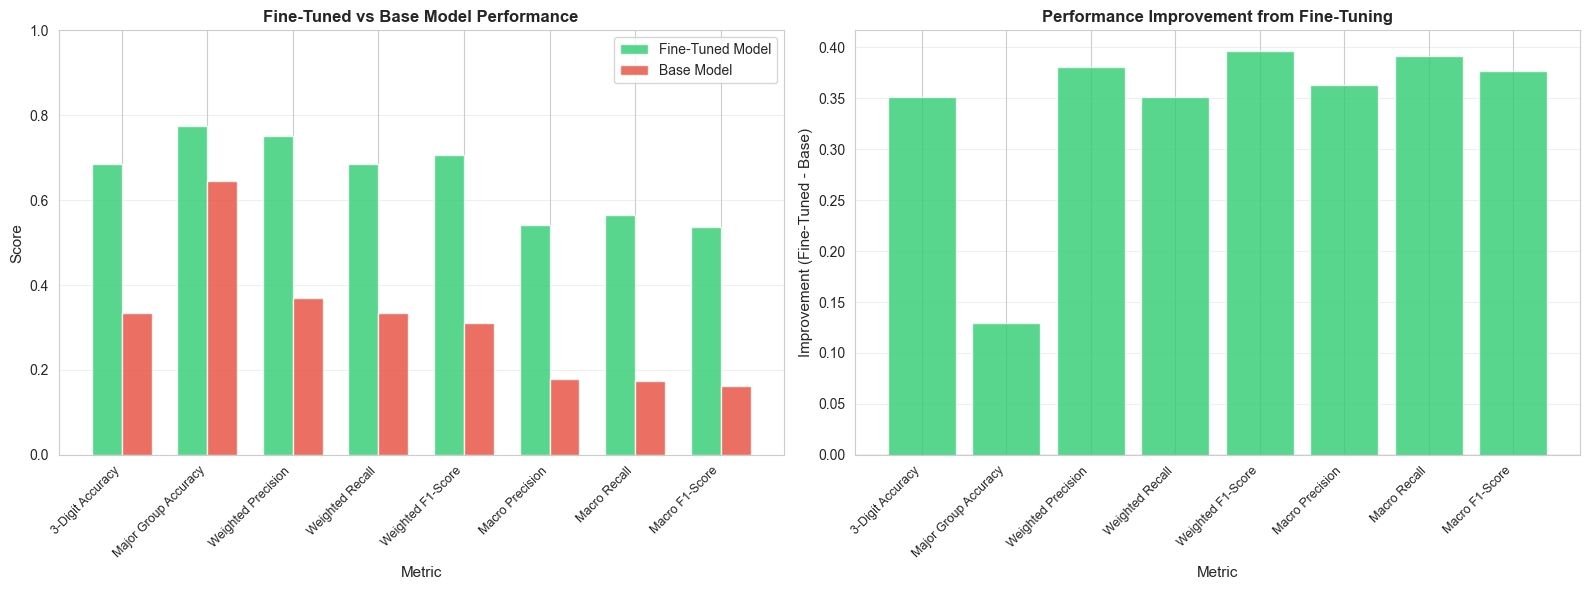


Average improvement (across all metrics): 0.3426
Largest improvement: 0.3968 (Weighted F1-Score)
Smallest improvement: 0.1298 (Major Group Accuracy)


In [86]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Convert string metrics back to float for plotting
fine_tuned_values = [float(v) for v in comparison_data["Fine-Tuned Model"]]
base_values = [float(v) for v in comparison_data["Base Model"]]
metric_names = comparison_data["Metric"]

# Plot 1: Side-by-side comparison
ax1 = axes[0]
x = np.arange(len(metric_names))
width = 0.35

bars1 = ax1.bar(x - width/2, fine_tuned_values, width, label='Fine-Tuned Model', alpha=0.8, color='#2ecc71')
bars2 = ax1.bar(x + width/2, base_values, width, label='Base Model', alpha=0.8, color='#e74c3c')

ax1.set_xlabel('Metric', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Fine-Tuned vs Base Model Performance', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# Plot 2: Improvement bars
ax2 = axes[1]
improvements = [fine_tuned_values[i] - base_values[i] for i in range(len(fine_tuned_values))]
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]

bars = ax2.bar(x, improvements, alpha=0.8, color=colors)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Metric', fontsize=11)
ax2.set_ylabel('Improvement (Fine-Tuned - Base)', fontsize=11)
ax2.set_title('Performance Improvement from Fine-Tuning', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metric_names, rotation=45, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nAverage improvement (across all metrics): {np.mean(improvements):.4f}")
print(f"Largest improvement: {max(improvements):.4f} ({metric_names[improvements.index(max(improvements))]})")
if min(improvements) < 0:
    print(f"Largest decline: {min(improvements):.4f} ({metric_names[improvements.index(min(improvements))]})")
else:
    print(f"Smallest improvement: {min(improvements):.4f} ({metric_names[improvements.index(min(improvements))]})")

### 3c. Multi-Level Comparison: Fine-Tuned vs Base Model

Compare performance at 3-digit, 2-digit, and 1-digit (major group) levels.

In [87]:
# Extract 2-digit and 1-digit ISCO codes for FINE-TUNED model
test_data_clean["true_isco_2digit"] = test_data_clean["true_isco"].astype(str).str[:2].astype(int)
test_data_clean["predicted_isco_2digit"] = test_data_clean["predicted_isco"].astype(str).str[:2].astype(int)

test_data_clean["true_isco_1digit"] = test_data_clean["true_isco"].astype(str).str[0].astype(int)
test_data_clean["predicted_isco_1digit"] = test_data_clean["predicted_isco"].astype(str).str[0].astype(int)

# Extract 2-digit and 1-digit ISCO codes for BASE model
base_test_data_clean["true_isco_2digit"] = base_test_data_clean["true_isco"].astype(str).str[:2].astype(int)
base_test_data_clean["predicted_isco_2digit_base"] = base_test_data_clean["predicted_isco_base"].astype(str).str[:2].astype(int)

base_test_data_clean["true_isco_1digit"] = base_test_data_clean["true_isco"].astype(str).str[0].astype(int)
base_test_data_clean["predicted_isco_1digit_base"] = base_test_data_clean["predicted_isco_base"].astype(str).str[0].astype(int)

# Calculate metrics at each level for FINE-TUNED model
metrics_by_level_ft = []

# 3-digit level
acc_3d = accuracy_score(test_data_clean["true_isco"], test_data_clean["predicted_isco"])
prec_3d_w, rec_3d_w, f1_3d_w, _ = precision_recall_fscore_support(
    test_data_clean["true_isco"], test_data_clean["predicted_isco"], 
    average="weighted", zero_division=0
)
prec_3d_m, rec_3d_m, f1_3d_m, _ = precision_recall_fscore_support(
    test_data_clean["true_isco"], test_data_clean["predicted_isco"], 
    average="macro", zero_division=0
)

metrics_by_level_ft.append({
    "Level": "3-digit",
    "N_Classes": test_data_clean["true_isco"].nunique(),
    "Accuracy": acc_3d,
    "Precision_Weighted": prec_3d_w,
    "Recall_Weighted": rec_3d_w,
    "F1_Weighted": f1_3d_w,
    "Precision_Macro": prec_3d_m,
    "Recall_Macro": rec_3d_m,
    "F1_Macro": f1_3d_m,
})

# 2-digit level
acc_2d = accuracy_score(test_data_clean["true_isco_2digit"], test_data_clean["predicted_isco_2digit"])
prec_2d_w, rec_2d_w, f1_2d_w, _ = precision_recall_fscore_support(
    test_data_clean["true_isco_2digit"], test_data_clean["predicted_isco_2digit"], 
    average="weighted", zero_division=0
)
prec_2d_m, rec_2d_m, f1_2d_m, _ = precision_recall_fscore_support(
    test_data_clean["true_isco_2digit"], test_data_clean["predicted_isco_2digit"], 
    average="macro", zero_division=0
)

metrics_by_level_ft.append({
    "Level": "2-digit",
    "N_Classes": test_data_clean["true_isco_2digit"].nunique(),
    "Accuracy": acc_2d,
    "Precision_Weighted": prec_2d_w,
    "Recall_Weighted": rec_2d_w,
    "F1_Weighted": f1_2d_w,
    "Precision_Macro": prec_2d_m,
    "Recall_Macro": rec_2d_m,
    "F1_Macro": f1_2d_m,
})

# 1-digit level (major groups)
acc_1d = accuracy_score(test_data_clean["true_isco_1digit"], test_data_clean["predicted_isco_1digit"])
prec_1d_w, rec_1d_w, f1_1d_w, _ = precision_recall_fscore_support(
    test_data_clean["true_isco_1digit"], test_data_clean["predicted_isco_1digit"], 
    average="weighted", zero_division=0
)
prec_1d_m, rec_1d_m, f1_1d_m, _ = precision_recall_fscore_support(
    test_data_clean["true_isco_1digit"], test_data_clean["predicted_isco_1digit"], 
    average="macro", zero_division=0
)

metrics_by_level_ft.append({
    "Level": "1-digit",
    "N_Classes": test_data_clean["true_isco_1digit"].nunique(),
    "Accuracy": acc_1d,
    "Precision_Weighted": prec_1d_w,
    "Recall_Weighted": rec_1d_w,
    "F1_Weighted": f1_1d_w,
    "Precision_Macro": prec_1d_m,
    "Recall_Macro": rec_1d_m,
    "F1_Macro": f1_1d_m,
})

# Calculate metrics at each level for BASE model
metrics_by_level_base = []

# 3-digit level
base_acc_3d = accuracy_score(base_test_data_clean["true_isco"], base_test_data_clean["predicted_isco_base"])
base_prec_3d_w, base_rec_3d_w, base_f1_3d_w, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco"], base_test_data_clean["predicted_isco_base"], 
    average="weighted", zero_division=0
)
base_prec_3d_m, base_rec_3d_m, base_f1_3d_m, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco"], base_test_data_clean["predicted_isco_base"], 
    average="macro", zero_division=0
)

metrics_by_level_base.append({
    "Level": "3-digit",
    "N_Classes": base_test_data_clean["true_isco"].nunique(),
    "Accuracy": base_acc_3d,
    "Precision_Weighted": base_prec_3d_w,
    "Recall_Weighted": base_rec_3d_w,
    "F1_Weighted": base_f1_3d_w,
    "Precision_Macro": base_prec_3d_m,
    "Recall_Macro": base_rec_3d_m,
    "F1_Macro": base_f1_3d_m,
})

# 2-digit level
base_acc_2d = accuracy_score(base_test_data_clean["true_isco_2digit"], base_test_data_clean["predicted_isco_2digit_base"])
base_prec_2d_w, base_rec_2d_w, base_f1_2d_w, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco_2digit"], base_test_data_clean["predicted_isco_2digit_base"], 
    average="weighted", zero_division=0
)
base_prec_2d_m, base_rec_2d_m, base_f1_2d_m, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco_2digit"], base_test_data_clean["predicted_isco_2digit_base"], 
    average="macro", zero_division=0
)

metrics_by_level_base.append({
    "Level": "2-digit",
    "N_Classes": base_test_data_clean["true_isco_2digit"].nunique(),
    "Accuracy": base_acc_2d,
    "Precision_Weighted": base_prec_2d_w,
    "Recall_Weighted": base_rec_2d_w,
    "F1_Weighted": base_f1_2d_w,
    "Precision_Macro": base_prec_2d_m,
    "Recall_Macro": base_rec_2d_m,
    "F1_Macro": base_f1_2d_m,
})

# 1-digit level (major groups)
base_acc_1d = accuracy_score(base_test_data_clean["true_isco_1digit"], base_test_data_clean["predicted_isco_1digit_base"])
base_prec_1d_w, base_rec_1d_w, base_f1_1d_w, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco_1digit"], base_test_data_clean["predicted_isco_1digit_base"], 
    average="weighted", zero_division=0
)
base_prec_1d_m, base_rec_1d_m, base_f1_1d_m, _ = precision_recall_fscore_support(
    base_test_data_clean["true_isco_1digit"], base_test_data_clean["predicted_isco_1digit_base"], 
    average="macro", zero_division=0
)

metrics_by_level_base.append({
    "Level": "1-digit",
    "N_Classes": base_test_data_clean["true_isco_1digit"].nunique(),
    "Accuracy": base_acc_1d,
    "Precision_Weighted": base_prec_1d_w,
    "Recall_Weighted": base_rec_1d_w,
    "F1_Weighted": base_f1_1d_w,
    "Precision_Macro": base_prec_1d_m,
    "Recall_Macro": base_rec_1d_m,
    "F1_Macro": base_f1_1d_m,
})

# Create DataFrames
metrics_df_ft = pd.DataFrame(metrics_by_level_ft)
metrics_df_base = pd.DataFrame(metrics_by_level_base)

print("=" * 110)
print("MULTI-LEVEL PERFORMANCE COMPARISON: FINE-TUNED vs BASE MODEL")
print("=" * 110)
print("\nFINE-TUNED MODEL - Weighted metrics (account for class imbalance):")
print(metrics_df_ft[["Level", "N_Classes", "Accuracy", "Precision_Weighted", "Recall_Weighted", "F1_Weighted"]].to_string(index=False))

print("\n" + "-" * 110)
print("BASE MODEL - Weighted metrics (account for class imbalance):")
print(metrics_df_base[["Level", "N_Classes", "Accuracy", "Precision_Weighted", "Recall_Weighted", "F1_Weighted"]].to_string(index=False))

print("\n" + "=" * 110)
print("\nFINE-TUNED MODEL - Macro metrics (treat all classes equally):")
print(metrics_df_ft[["Level", "N_Classes", "Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]].to_string(index=False))

print("\n" + "-" * 110)
print("BASE MODEL - Macro metrics (treat all classes equally):")
print(metrics_df_base[["Level", "N_Classes", "Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]].to_string(index=False))
print("=" * 110)

MULTI-LEVEL PERFORMANCE COMPARISON: FINE-TUNED vs BASE MODEL

FINE-TUNED MODEL - Weighted metrics (account for class imbalance):
  Level  N_Classes  Accuracy  Precision_Weighted  Recall_Weighted  F1_Weighted
3-digit         46  0.684211            0.751468         0.684211     0.706704
2-digit         21  0.726316            0.785454         0.726316     0.747885
1-digit          6  0.775439            0.819013         0.775439     0.792421

--------------------------------------------------------------------------------------------------------------
BASE MODEL - Weighted metrics (account for class imbalance):
  Level  N_Classes  Accuracy  Precision_Weighted  Recall_Weighted  F1_Weighted
3-digit         46  0.333333            0.370453         0.333333     0.309936
2-digit         21  0.463158            0.547945         0.463158     0.459229
1-digit          6  0.645614            0.688391         0.645614     0.639935


FINE-TUNED MODEL - Macro metrics (treat all classes equally):
  

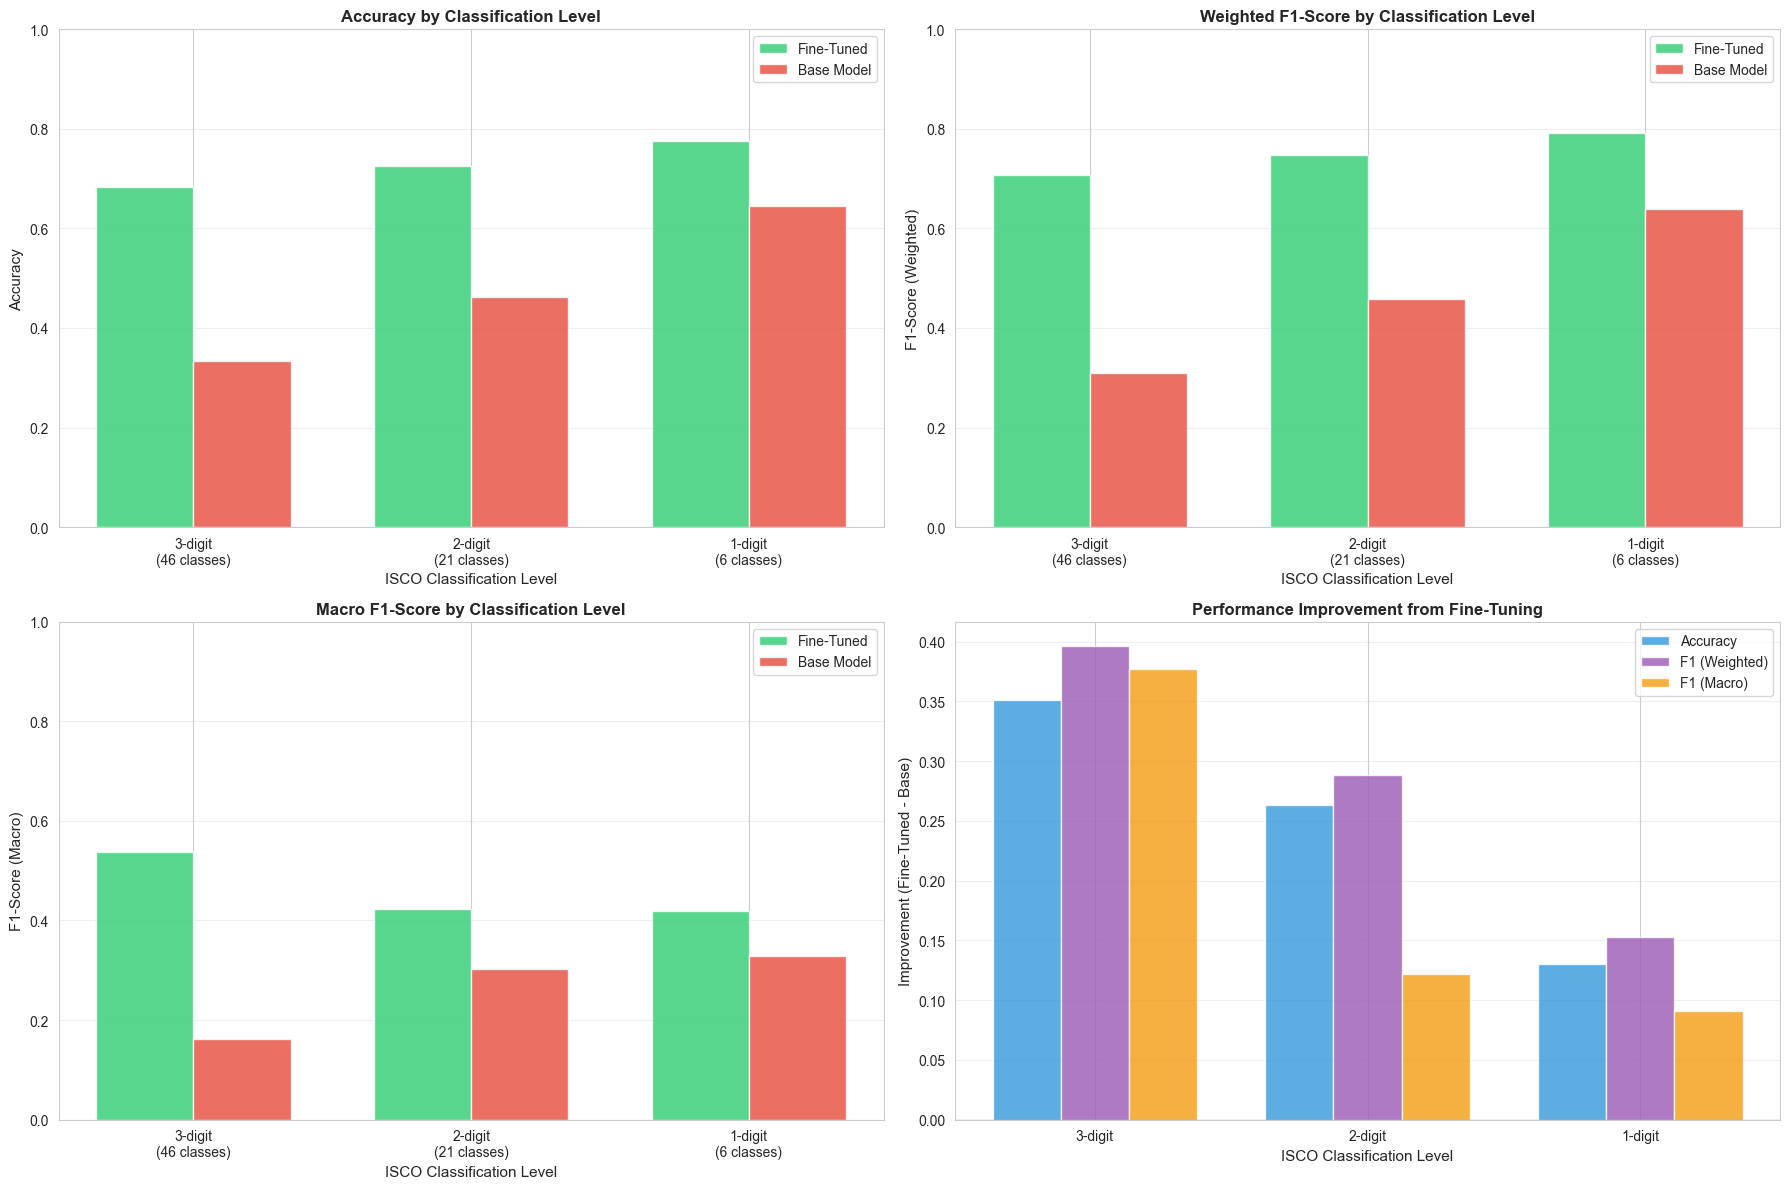


Note: Fine-tuned model consistently outperforms base model across all classification levels.
Improvements are most pronounced at the 3-digit level (most granular classification).


In [88]:
# Visualize multi-level performance comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Prepare data
levels = ["3-digit", "2-digit", "1-digit"]
x = np.arange(len(levels))
width = 0.35

# Plot 1: Weighted Accuracy
ax1 = axes[0, 0]
ft_acc_weighted = [metrics_df_ft.iloc[i]["Accuracy"] for i in range(3)]
base_acc_weighted = [metrics_df_base.iloc[i]["Accuracy"] for i in range(3)]

ax1.bar(x - width/2, ft_acc_weighted, width, label='Fine-Tuned', alpha=0.8, color='#2ecc71')
ax1.bar(x + width/2, base_acc_weighted, width, label='Base Model', alpha=0.8, color='#e74c3c')
ax1.set_xlabel('ISCO Classification Level', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy by Classification Level', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{levels[i]}\n({metrics_df_ft.iloc[i]['N_Classes']} classes)" for i in range(3)])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# Plot 2: Weighted F1-Score
ax2 = axes[0, 1]
ft_f1_weighted = [metrics_df_ft.iloc[i]["F1_Weighted"] for i in range(3)]
base_f1_weighted = [metrics_df_base.iloc[i]["F1_Weighted"] for i in range(3)]

ax2.bar(x - width/2, ft_f1_weighted, width, label='Fine-Tuned', alpha=0.8, color='#2ecc71')
ax2.bar(x + width/2, base_f1_weighted, width, label='Base Model', alpha=0.8, color='#e74c3c')
ax2.set_xlabel('ISCO Classification Level', fontsize=11)
ax2.set_ylabel('F1-Score (Weighted)', fontsize=11)
ax2.set_title('Weighted F1-Score by Classification Level', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{levels[i]}\n({metrics_df_ft.iloc[i]['N_Classes']} classes)" for i in range(3)])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.0])

# Plot 3: Macro F1-Score
ax3 = axes[1, 0]
ft_f1_macro = [metrics_df_ft.iloc[i]["F1_Macro"] for i in range(3)]
base_f1_macro = [metrics_df_base.iloc[i]["F1_Macro"] for i in range(3)]

ax3.bar(x - width/2, ft_f1_macro, width, label='Fine-Tuned', alpha=0.8, color='#2ecc71')
ax3.bar(x + width/2, base_f1_macro, width, label='Base Model', alpha=0.8, color='#e74c3c')
ax3.set_xlabel('ISCO Classification Level', fontsize=11)
ax3.set_ylabel('F1-Score (Macro)', fontsize=11)
ax3.set_title('Macro F1-Score by Classification Level', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f"{levels[i]}\n({metrics_df_ft.iloc[i]['N_Classes']} classes)" for i in range(3)])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 1.0])

# Plot 4: Improvement (Fine-Tuned - Base)
ax4 = axes[1, 1]
improvements_acc = [ft_acc_weighted[i] - base_acc_weighted[i] for i in range(3)]
improvements_f1w = [ft_f1_weighted[i] - base_f1_weighted[i] for i in range(3)]
improvements_f1m = [ft_f1_macro[i] - base_f1_macro[i] for i in range(3)]

width_imp = 0.25
ax4.bar(x - width_imp, improvements_acc, width_imp, label='Accuracy', alpha=0.8, color='#3498db')
ax4.bar(x, improvements_f1w, width_imp, label='F1 (Weighted)', alpha=0.8, color='#9b59b6')
ax4.bar(x + width_imp, improvements_f1m, width_imp, label='F1 (Macro)', alpha=0.8, color='#f39c12')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('ISCO Classification Level', fontsize=11)
ax4.set_ylabel('Improvement (Fine-Tuned - Base)', fontsize=11)
ax4.set_title('Performance Improvement from Fine-Tuning', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([f"{levels[i]}" for i in range(3)])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNote: Fine-tuned model consistently outperforms base model across all classification levels.")
print(f"Improvements are most pronounced at the 3-digit level (most granular classification).")

## 4. Performance by Confidence Score

Analyze how accuracy varies with the confidence score of manual classifications.

Performance by Manual Classification Confidence Score:

 Confidence_Score  N_Examples  3-Digit_Accuracy  Major_Group_Accuracy
              1.0          24          0.333333              0.458333
              2.0          36          0.555556              0.583333
              3.0          46          0.630435              0.739130
              4.0          67          0.686567              0.776119
              5.0         108          0.842593              0.944444


/Users/willbackes/miniforge3/envs/expscore/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/willbackes/miniforge3/envs/expscore/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/willbackes/miniforge3/envs/expscore/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


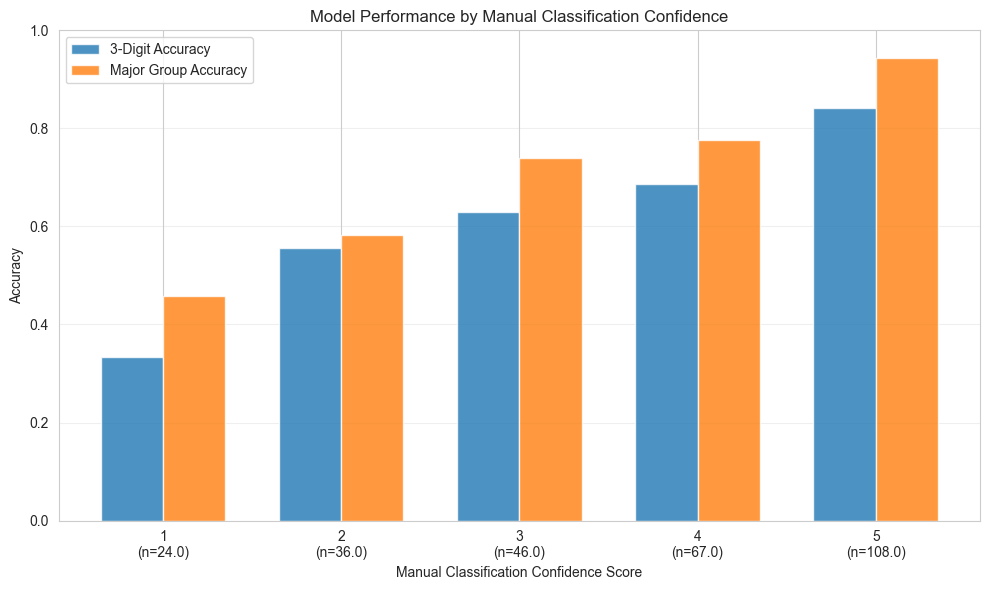

In [89]:
# Performance by confidence score
confidence_results = []
for conf_score in sorted(test_data_clean["confidence_score"].dropna().unique()):
    subset = test_data_clean[test_data_clean["confidence_score"] == conf_score]
    acc_3digit = accuracy_score(subset["true_isco"], subset["predicted_isco"])
    acc_major = accuracy_score(subset["true_major_group"], subset["predicted_major_group"])
    
    confidence_results.append({
        "Confidence_Score": conf_score,
        "N_Examples": len(subset),
        "3-Digit_Accuracy": acc_3digit,
        "Major_Group_Accuracy": acc_major,
    })

conf_df = pd.DataFrame(confidence_results)

print("Performance by Manual Classification Confidence Score:\n")
print(conf_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(conf_df))
width = 0.35

ax.bar(x - width/2, conf_df["3-Digit_Accuracy"], width, label='3-Digit Accuracy', alpha=0.8)
ax.bar(x + width/2, conf_df["Major_Group_Accuracy"], width, label='Major Group Accuracy', alpha=0.8)
ax.set_xlabel('Manual Classification Confidence Score')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance by Manual Classification Confidence')
ax.set_xticks(x)
ax.set_xticklabels([f"{int(row['Confidence_Score'])}\n(n={row['N_Examples']})" 
                     for _, row in conf_df.iterrows()])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

## 5. Performance by Major Group

Performance by ISCO-08 Major Group:

Group                                    Name  N_Examples  3-Digit_Accuracy  Major_Group_Accuracy
    1                                Managers          51          0.666667              0.784314
    2                           Professionals         177          0.717514              0.796610
    3 Technicians and Associate Professionals          36          0.555556              0.694444
    4                Clerical Support Workers          12          0.500000              0.583333
    5               Service and Sales Workers           8          1.000000              1.000000
    9                  Elementary Occupations           1          0.000000              0.000000


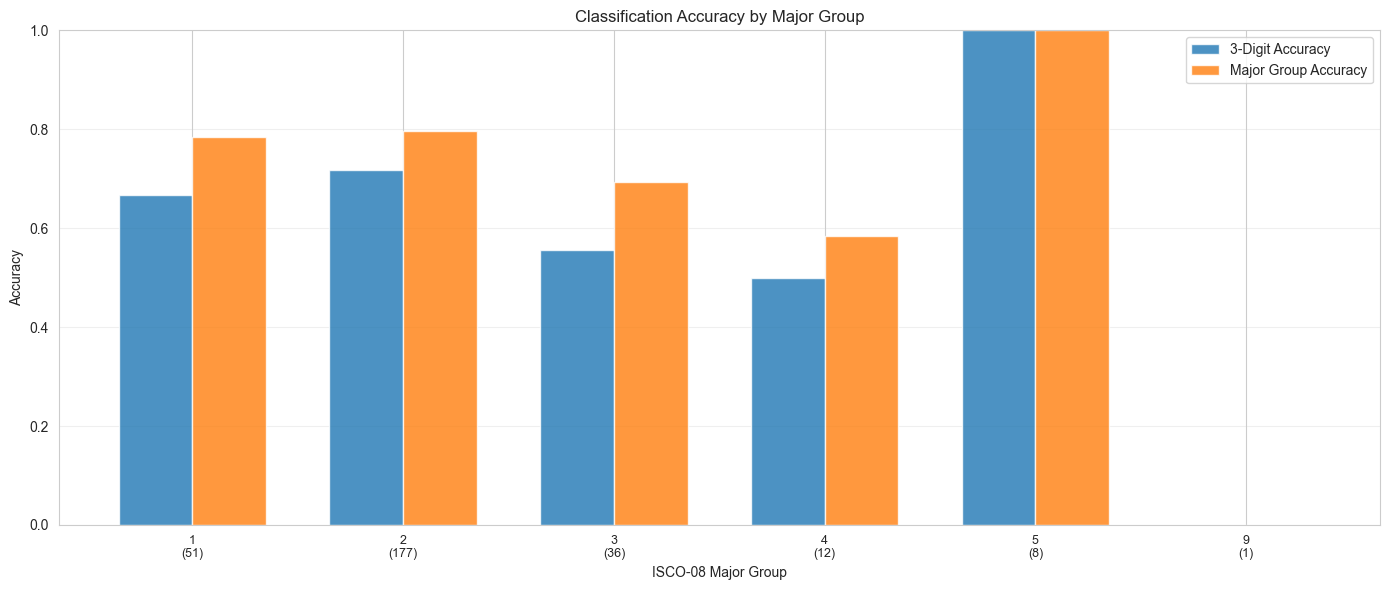

In [90]:
# Calculate metrics for each major group
major_group_results = []
for group, name in sorted(major_groups.items()):
    mask = test_data_clean["true_major_group"] == group
    if mask.sum() == 0:
        continue
    
    subset = test_data_clean[mask]
    acc_3digit = accuracy_score(subset["true_isco"], subset["predicted_isco"])
    acc_major = accuracy_score(subset["true_major_group"], subset["predicted_major_group"])
    
    major_group_results.append({
        "Group": group,
        "Name": name,
        "N_Examples": mask.sum(),
        "3-Digit_Accuracy": acc_3digit,
        "Major_Group_Accuracy": acc_major,
    })

results_df = pd.DataFrame(major_group_results)
print("Performance by ISCO-08 Major Group:\n")
print(results_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df["3-Digit_Accuracy"], width, label='3-Digit Accuracy', alpha=0.8)
ax.bar(x + width/2, results_df["Major_Group_Accuracy"], width, label='Major Group Accuracy', alpha=0.8)
ax.set_xlabel('ISCO-08 Major Group')
ax.set_ylabel('Accuracy')
ax.set_title('Classification Accuracy by Major Group')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Group']}\n({row['N_Examples']})" for _, row in results_df.iterrows()], fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

## 6. Detailed Classification Report

In [91]:
# Generate full classification report
print("Classification Report (per-class metrics):\n")
report = classification_report(
    test_data_clean["true_isco"],
    test_data_clean["predicted_isco"],
    zero_division=0,
    output_dict=True,
)

# Convert to DataFrame for better display
report_df = pd.DataFrame(report).transpose()

# Filter to only ISCO codes (not summary rows)
all_categories = pd.concat([
    test_data_clean["true_isco"], 
    test_data_clean["predicted_isco"]
]).unique()
report_df_codes = report_df[report_df.index.isin(all_categories)]
report_df_codes = report_df_codes.sort_values('support', ascending=False)

# Show top categories by support
print("Top 20 categories by number of examples:\n")
print(report_df_codes.head(20).to_string())

# Show summary statistics
print("\n" + "=" * 70)
print("Summary Statistics:")
print("=" * 70)
print(report_df.loc[["accuracy", "macro avg", "weighted avg"]].to_string())

Classification Report (per-class metrics):

Top 20 categories by number of examples:

Empty DataFrame
Columns: [precision, recall, f1-score, support]
Index: []

Summary Statistics:
              precision    recall  f1-score     support
accuracy       0.684211  0.684211  0.684211    0.684211
macro avg      0.541184  0.565096  0.538045  285.000000
weighted avg   0.751468  0.684211  0.706704  285.000000


## 7. Confusion Matrix Analysis

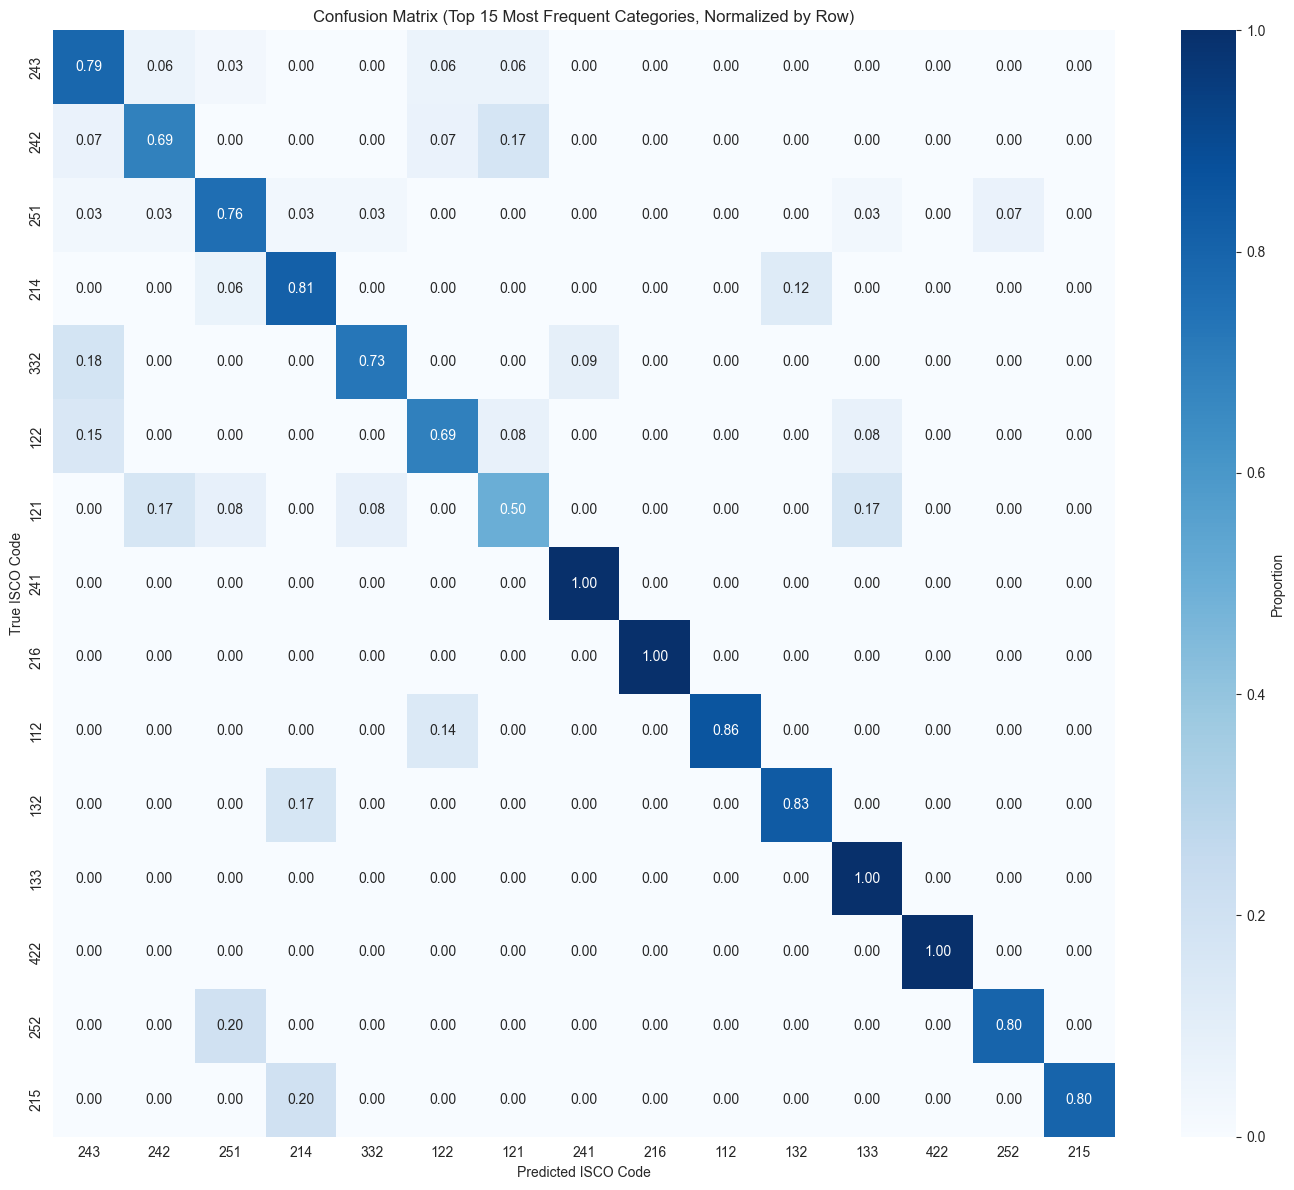

Confusion matrix shows 15 most frequent categories
Diagonal elements represent correct classifications


In [92]:
# Get most frequent categories for confusion matrix
top_categories = test_data_clean["true_isco"].value_counts().head(15).index.tolist()
mask = test_data_clean["true_isco"].isin(top_categories)
subset = test_data_clean[mask]

# Create confusion matrix
cm = confusion_matrix(
    subset["true_isco"],
    subset["predicted_isco"],
    labels=top_categories,
)

# Normalize by row (true labels) to show percentages
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=top_categories,
    yticklabels=top_categories,
    cbar_kws={'label': 'Proportion'},
)
plt.xlabel('Predicted ISCO Code')
plt.ylabel('True ISCO Code')
plt.title(f'Confusion Matrix (Top {len(top_categories)} Most Frequent Categories, Normalized by Row)')
plt.tight_layout()
plt.show()

print(f"Confusion matrix shows {len(top_categories)} most frequent categories")
print(f"Diagonal elements represent correct classifications")

## 8. Error Analysis

In [58]:
# Find all errors
errors = test_data_clean[test_data_clean["true_isco"] != test_data_clean["predicted_isco"]].copy()
errors["error_pair"] = errors["true_isco"].astype(str) + " → " + errors["predicted_isco"].astype(str)
errors["same_major_group"] = errors["true_major_group"] == errors["predicted_major_group"]

print(f"Total errors: {len(errors)} ({len(errors)/len(test_data_clean)*100:.2f}%)\n")

# Most common error pairs
print("Top 20 Most Common Misclassifications:\n")
error_counts = errors["error_pair"].value_counts().head(20)
for i, (pair, count) in enumerate(error_counts.items(), 1):
    true_code, pred_code = pair.split(" → ")
    print(f"{i:2d}. {pair:15s} ({count:3d} occurrences)")

# Check if errors are within same major group
within_major = errors["same_major_group"].sum()
print(f"\n" + "="*70)
print(f"Errors within same major group: {within_major}/{len(errors)} ({within_major/len(errors)*100:.1f}%)")
print(f"Errors across major groups: {len(errors)-within_major}/{len(errors)} ({(len(errors)-within_major)/len(errors)*100:.1f}%)")
print("="*70)

Total errors: 91 (31.93%)

Top 20 Most Common Misclassifications:

 1. 242 → 121       (  5 occurrences)
 2. 122 → 243       (  3 occurrences)
 3. 243 → 242       (  2 occurrences)
 4. 332 → 622       (  2 occurrences)
 5. 243 → 121       (  2 occurrences)
 6. 242 → 243       (  2 occurrences)
 7. 332 → 243       (  2 occurrences)
 8. 243 → 122       (  2 occurrences)
 9. 251 → 252       (  2 occurrences)
10. 214 → 132       (  2 occurrences)
11. 214 → 311       (  2 occurrences)
12. 121 → 311       (  2 occurrences)
13. 242 → 122       (  2 occurrences)
14. 121 → 242       (  2 occurrences)
15. 121 → 133       (  2 occurrences)
16. 242 → 311       (  2 occurrences)
17. 334 → 311       (  1 occurrences)
18. 132 → 722       (  1 occurrences)
19. 333 → 243       (  1 occurrences)
20. 241 → 421       (  1 occurrences)

Errors within same major group: 26/91 (28.6%)
Errors across major groups: 65/91 (71.4%)


In [59]:
# Show example errors with job titles
print("Sample Misclassifications with Job Titles:\n")
sample_errors = errors.sample(min(15, len(errors)), random_state=42) if len(errors) > 0 else errors

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    print(f"{i}. Job: {row['content'][:70]}...")
    print(f"   True: {row['true_isco']}, Predicted: {row['predicted_isco']}")
    print(f"   Confidence: {row['confidence_score']}/5", end="")
    if not row["same_major_group"]:
        print(" ⚠️ Different major groups")
    else:
        print(" (same major group)")
    print()

Sample Misclassifications with Job Titles:

1. Job: Head Of International Sales. Industry: Medical Device...
   True: 122, Predicted: 143
   Confidence: 5.0/5 (same major group)

2. Job: Referent Steering Material flow. Industry: Automotive...
   True: 243, Predicted: 432
   Confidence: 1.0/5 ⚠️ Different major groups

3. Job: Leiter Rating Privatkunden. Industry: Information Technology & Service...
   True: 121, Predicted: 242
   Confidence: 1.0/5 ⚠️ Different major groups

4. Job: Sustainability Consultant. Industry: Management Consulting...
   True: 242, Predicted: 121
   Confidence: 2.0/5 ⚠️ Different major groups

5. Job: Digital Marketing Manager. Industry: Marketing & Advertising...
   True: 122, Predicted: 243
   Confidence: 5.0/5 ⚠️ Different major groups

6. Job: IT Project Manager. Industry: Transportation/Trucking/Railroad...
   True: 251, Predicted: 351
   Confidence: 4.0/5 ⚠️ Different major groups

7. Job: Consultant. Industry: Medical Device...
   True: 242, Predicted: 

In [60]:
# Analyze errors by confidence score
if len(errors) > 0:
    error_by_conf = errors.groupby("confidence_score").size()
    total_by_conf = test_data_clean.groupby("confidence_score").size()
    error_rate_by_conf = (error_by_conf / total_by_conf * 100).fillna(0)
    
    print("Error Rate by Confidence Score:")
    print("="*70)
    for conf in sorted(test_data_clean["confidence_score"].unique()):
        n_total = total_by_conf.get(conf, 0)
        n_errors = error_by_conf.get(conf, 0)
        error_rate = error_rate_by_conf.get(conf, 0)
        print(f"Confidence {conf}: {n_errors}/{n_total} errors ({error_rate:.1f}%)")
    print("="*70)

Error Rate by Confidence Score:
Confidence 1.0: 16/24 errors (66.7%)
Confidence 2.0: 16/36 errors (44.4%)
Confidence 3.0: 17/46 errors (37.0%)
Confidence 4.0: 21/67 errors (31.3%)
Confidence 5.0: 18/108 errors (16.7%)
Confidence nan: 0/0 errors (0.0%)


## 9. Summary Statistics for Thesis

In [61]:
# Load fine-tune metadata
metadata_path = OCCUPATION_DATA_BLD / "fine_tune_metadata.csv"
metadata = pd.read_csv(metadata_path)

print("=" * 70)
print("SUMMARY STATISTICS - FINE-TUNED MODEL TEST SET EVALUATION")
print("=" * 70)

print("\n1. MODEL INFORMATION")
print("-" * 70)
print(f"Fine-tuned model ID: {metadata['fine_tune_id'].iloc[0]}")
print(f"Model suffix: {metadata['model_suffix'].iloc[0]}")
print(f"Base model: {metadata['model'].iloc[0]}")
print(f"Training examples used: {metadata['n_training_examples'].iloc[0]:,}")
print(f"Validation examples used: {metadata['n_validation_examples'].iloc[0]:,}")
print(f"Number of epochs: {metadata['n_epochs'].iloc[0]}")

print("\n2. TEST SET CHARACTERISTICS")
print("-" * 70)
print(f"Total test examples: {len(test_data_clean)}")
print(f"Unique ISCO-08 3-digit codes: {test_data_clean['true_isco'].nunique()}")
print(f"ISCO-08 major groups represented: {test_data_clean['true_major_group'].nunique()}")
print(f"Manual classification confidence: 1-5 scale")

print("\n3. OVERALL MODEL PERFORMANCE")
print("-" * 70)
print(f"3-Digit ISCO Code Accuracy: {accuracy_3digit*100:.2f}%")
print(f"Major Group (1-digit) Accuracy: {accuracy_major*100:.2f}%")
print(f"Correct predictions: {correct}/{len(test_data_clean)}")
print(f"Incorrect predictions: {incorrect}/{len(test_data_clean)}")

print("\n4. WEIGHTED METRICS (accounts for class imbalance)")
print("-" * 70)
print(f"Precision: {precision_weighted:.4f}")
print(f"Recall:    {recall_weighted:.4f}")
print(f"F1-Score:  {f1_weighted:.4f}")

print("\n5. MACRO METRICS (treats all classes equally)")
print("-" * 70)
print(f"Precision: {precision_macro:.4f}")
print(f"Recall:    {recall_macro:.4f}")
print(f"F1-Score:  {f1_macro:.4f}")

print("\n6. ERROR ANALYSIS")
print("-" * 70)
print(f"Total misclassifications: {len(errors)} ({len(errors)/len(test_data_clean)*100:.2f}%)")
if len(errors) > 0:
    print(f"Errors within same major group: {within_major} ({within_major/len(errors)*100:.1f}% of errors)")
    print(f"Errors across major groups: {len(errors)-within_major} ({(len(errors)-within_major)/len(errors)*100:.1f}% of errors)")

print("\n7. PERFORMANCE RANGE BY MAJOR GROUP")
print("-" * 70)
best_group = results_df.loc[results_df["3-Digit_Accuracy"].idxmax()]
worst_group = results_df.loc[results_df["3-Digit_Accuracy"].idxmin()]
print(f"Best performing group: {best_group['Group']} ({best_group['Name']}) - {best_group['3-Digit_Accuracy']*100:.1f}%")
print(f"Worst performing group: {worst_group['Group']} ({worst_group['Name']}) - {worst_group['3-Digit_Accuracy']*100:.1f}%")
print(f"Mean major group accuracy: {results_df['3-Digit_Accuracy'].mean()*100:.1f}%")

print("\n" + "=" * 70)
print("END OF SUMMARY")
print("=" * 70)

SUMMARY STATISTICS - FINE-TUNED MODEL TEST SET EVALUATION

1. MODEL INFORMATION
----------------------------------------------------------------------
Fine-tuned model ID: isco_classifier_04
Model suffix: isco-classifier-v04
Base model: gpt-4o-mini-2024-07-18
Training examples used: 7,496
Validation examples used: 0
Number of epochs: 3

2. TEST SET CHARACTERISTICS
----------------------------------------------------------------------
Total test examples: 285
Unique ISCO-08 3-digit codes: 46
ISCO-08 major groups represented: 6
Manual classification confidence: 1-5 scale

3. OVERALL MODEL PERFORMANCE
----------------------------------------------------------------------
3-Digit ISCO Code Accuracy: 68.07%
Major Group (1-digit) Accuracy: 77.19%
Correct predictions: 194/285
Incorrect predictions: 91/285

4. WEIGHTED METRICS (accounts for class imbalance)
----------------------------------------------------------------------
Precision: 0.7468
Recall:    0.6807
F1-Score:  0.7028

5. MACRO MET